In [48]:
import numpy

from matplotlib import pyplot
from collections import defaultdict

from stedfm.datasets.restoration import get_dataset
from stedfm.configuration import Configuration
from stedfm.utils import savefig

DATASETS = [
    "ov-lqhq-mt",
    "unet-rcan-tub",
    "kt-lqhq-vgat",
    "kt-lqhq-gephyrin"
]

In [11]:
def compute_snr(image):
    signal = image.mean()
    noise = image.std()
    return signal / (noise + 1e-8)

In [13]:
cfg = Configuration()
cfg.in_channels = 1

per_dataset_statistics = {}
for dataset_name in DATASETS:
    print(f"Dataset: {dataset_name}")
    train_dataset, val_dataset, test_dataset = get_dataset(
        dataset_name, cfg=cfg
    )

    statistics = defaultdict(list)
    for noisy, cleaned in train_dataset:
        statistics["noisy"].append({
            "snr" : compute_snr(noisy.numpy()),
            "mean" : noisy.numpy().mean(),
            "std" : noisy.numpy().std()
        })
        statistics["cleaned"].append({
            "snr" : compute_snr(cleaned.numpy()),
            "mean" : cleaned.numpy().mean(),
            "std" : cleaned.numpy().std()
        })

    per_dataset_statistics[dataset_name] = statistics

Dataset: ov-lqhq-mt
Loading OV-LQHQ-MT dataset...


100%|██████████| 47/47 [00:00<00:00, 2263.75it/s]


Dataset: unet-rcan-tub


Processing dataset..: 100%|██████████| 19864/19864 [00:22<00:00, 901.44it/s] 


Mean: [0.07495069 0.16883548], Std: [0.1558464 0.0982101]


...

Mean: [0.02376724 0.04481272], Std: [0.04030968 0.03653723]


Processing dataset..: 100%|██████████| 374/374 [00:00<00:00, 2832.15it/s]


Mean: [0.02567552 0.05524644], Std: [0.0424266  0.04191163]


Processing dataset..: 100%|██████████| 374/374 [00:00<00:00, 2842.24it/s]


Mean: [0.02051764 0.04380109], Std: [0.03557255 0.03649775]


ov-lqhq-mt


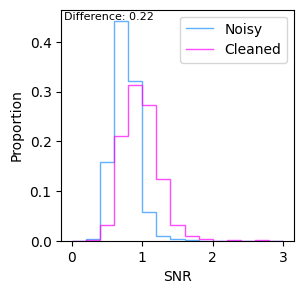

unet-rcan-tub


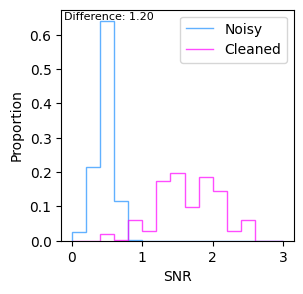

kt-lqhq-vgat


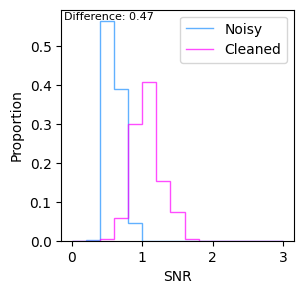

kt-lqhq-gephyrin


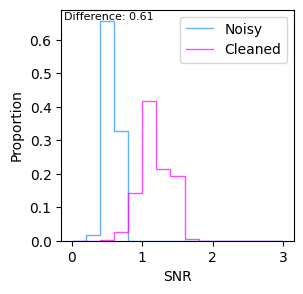

In [53]:
for dataset_name, statistics in per_dataset_statistics.items():
    print(dataset_name)
    
    fig, ax = pyplot.subplots(figsize=(3,3))
    values = [s["snr"] for s in statistics["noisy"]]
    counts, bins = numpy.histogram(values, bins=15, range=(0, 3.0))
    ax.stairs(counts / counts.sum(), bins, alpha=0.7, label="Noisy", color="dodgerblue", linewidth=1)

    values = [s["snr"] for s in statistics["cleaned"]]
    counts, bins = numpy.histogram(values, bins=15, range=(0, 3.0))
    ax.stairs(counts / counts.sum(), bins, alpha=0.7, label="Cleaned", color="fuchsia", linewidth=1)
    ax.set_xlabel("SNR")
    ax.set_ylabel("Proportion")
    ax.legend()

    difference_in_mean = numpy.mean(
        [s["snr"] for s in statistics["cleaned"]]
    ) - numpy.mean(
        [s["snr"] for s in statistics["noisy"]]
    )
    ax.annotate(f"Difference: {difference_in_mean:.2f}", xy=(0.01, 0.99), xycoords="axes fraction", va="top", fontsize=8)

    savefig(fig, f"./panels/dataset-statistics-snr-{dataset_name}")
    pyplot.show()